In [23]:
import os
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("/content")
CLS_PATH = DATA_DIR / "car_evaluation.csv"
REG_PATH = DATA_DIR / "CarPrice_Assignment.csv"

col_names = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]

def load_car_evaluation(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, header=None, names=col_names, dtype=str)
    for c in df.columns:
        df[c] = df[c].str.strip().str.lower()
    return df

df_cls = load_car_evaluation(CLS_PATH)
print(df_cls.head())
print("Shape:", df_cls.shape)
print("Target distribution:\n", df_cls["class"].value_counts())


  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc
Shape: (1728, 7)
Target distribution:
 class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [24]:
# Фичи и таргет
X_cls = df_cls.drop(columns=["class"])
y_cls = df_cls["class"]

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_cls
)

print("Train size:", X_train_cls.shape, "| Test size:", X_test_cls.shape)

# Все признаки категориальные
cat_cols_cls = X_train_cls.columns.tolist()

preprocess_cls = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_cls)
    ]
)


Train size: (1382, 6) | Test size: (346, 6)


Датасет небольшой, решающее дерево должно хорошо справиться с такой задачей

In [25]:
rf_clf_base = Pipeline(steps=[
    ("preprocess", preprocess_cls),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_clf_base.fit(X_train_cls, y_train_cls)
y_pred_rf_base = rf_clf_base.predict(X_test_cls)

acc_base = accuracy_score(y_test_cls, y_pred_rf_base)
f1_base = f1_score(y_test_cls, y_pred_rf_base, average="macro")

print(f"[RF Classifier — baseline]  Acc={acc_base:.4f} | F1-macro={f1_base:.4f}")
print(classification_report(y_test_cls, y_pred_rf_base))


[RF Classifier — baseline]  Acc=0.9682 | F1-macro=0.8969
              precision    recall  f1-score   support

         acc       0.94      0.96      0.95        77
        good       0.81      0.93      0.87        14
       unacc       0.99      0.99      0.99       242
       vgood       0.90      0.69      0.78        13

    accuracy                           0.97       346
   macro avg       0.91      0.89      0.90       346
weighted avg       0.97      0.97      0.97       346



Найдем оптимиальные параметры гридсерчем

In [26]:
param_grid_clf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 6, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_clf_pipe = Pipeline(steps=[
    ("preprocess", preprocess_cls),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

grid_rf_clf = GridSearchCV(
    estimator=rf_clf_pipe,
    param_grid=param_grid_clf,
    cv=cv_clf,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_rf_clf.fit(X_train_cls, y_train_cls)

print("Best params (RF classifier):", grid_rf_clf.best_params_)
print("Best CV score (F1-macro):", grid_rf_clf.best_score_)

rf_clf_best = grid_rf_clf.best_estimator_
y_pred_rf_imp = rf_clf_best.predict(X_test_cls)

acc_imp = accuracy_score(y_test_cls, y_pred_rf_imp)
f1_imp = f1_score(y_test_cls, y_pred_rf_imp, average="macro")

print(f"[RF Classifier — improved]  Acc={acc_imp:.4f} | F1-macro={f1_imp:.4f}")
print(classification_report(y_test_cls, y_pred_rf_imp))


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best params (RF classifier): {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV score (F1-macro): 0.8552267326463125
[RF Classifier — improved]  Acc=0.9798 | F1-macro=0.9670
              precision    recall  f1-score   support

         acc       0.94      0.97      0.96        77
        good       1.00      0.93      0.96        14
       unacc       0.99      0.99      0.99       242
       vgood       1.00      0.92      0.96        13

    accuracy                           0.98       346
   macro avg       0.98      0.95      0.97       346
weighted avg       0.98      0.98      0.98       346



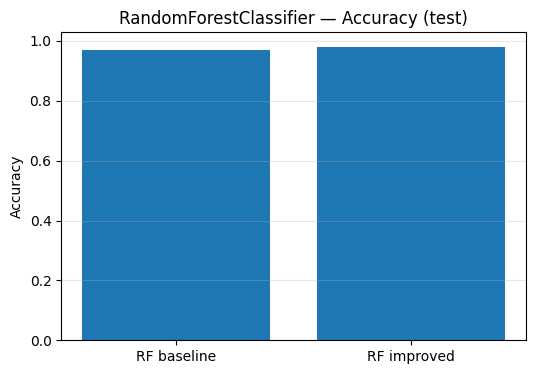

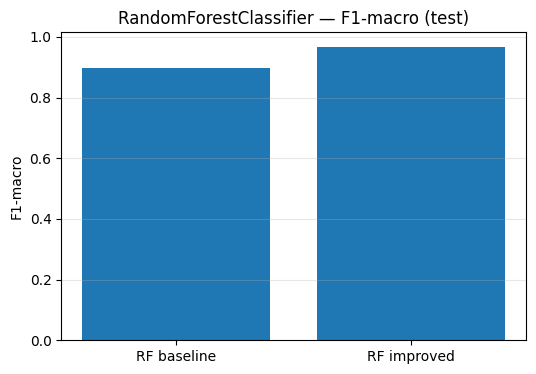

In [27]:
models_cls = ["RF baseline", "RF improved"]
accs = [acc_base, acc_imp]
f1s = [f1_base, f1_imp]

plt.figure(figsize=(6, 4))
plt.bar(models_cls, accs)
plt.ylabel("Accuracy")
plt.title("RandomForestClassifier — Accuracy (test)")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(models_cls, f1s)
plt.ylabel("F1-macro")
plt.title("RandomForestClassifier — F1-macro (test)")
plt.grid(axis="y", alpha=0.3)
plt.show()


# Регрессия

In [28]:
from sklearn.preprocessing import MinMaxScaler

def load_car_price_assignment(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    y = df["price"]
    X = df.drop(columns=["price", "car_ID"])
    # Выделяем бренд из имени модели
    if "CarName" in X.columns:
        carnames = X["CarName"].astype(str).str.strip().str.lower()
        X["brand"] = carnames.str.split("[ \-]", n=1, expand=True)[0]
        X = X.drop(columns=["CarName"])
    # Конвертация слов-чисел в числа (doornumber, cylindernumber)
    NUM_WORDS = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}
    for col in ["doornumber", "cylindernumber"]:
        if col in X.columns and X[col].dtype == object:
            X[col] = X[col].str.strip().str.lower().map(NUM_WORDS).astype("Int64")
    for c in X.columns:
        if X[c].dtype == object:
            X[c] = X[c].astype(str).str.strip().str.lower()
    return X, y

X_reg_raw, y_reg_raw = load_car_price_assignment(REG_PATH)
print("Regression dataset shape:", X_reg_raw.shape, "| target shape:", y_reg_raw.shape)
print("Sample columns:", list(X_reg_raw.columns)[:10], "...")
print("Target name:", y_reg_raw.name)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_raw, y_reg_raw,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Train size (reg):", X_train_reg.shape, "| Test size (reg):", X_test_reg.shape)


Regression dataset shape: (205, 24) | target shape: (205,)
Sample columns: ['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth'] ...
Target name: price
Train size (reg): (164, 24) | Test size (reg): (41, 24)


In [29]:
cat_cols_reg = [c for c in X_train_reg.columns if X_train_reg[c].dtype == "object"]
num_cols_reg = [c for c in X_train_reg.columns if c not in cat_cols_reg]

preprocess_reg = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols_reg),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_reg),
    ]
)


In [30]:
rf_reg_base = Pipeline(steps=[
    ("preprocess", preprocess_reg),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_reg_base.fit(X_train_reg, y_train_reg)
y_pred_rf_base_reg = rf_reg_base.predict(X_test_reg)

mse_base = mean_squared_error(y_test_reg, y_pred_rf_base_reg)
mae_base = mean_absolute_error(y_test_reg, y_pred_rf_base_reg)
r2_base = r2_score(y_test_reg, y_pred_rf_base_reg)

print(f"[RF Regressor — baseline]  MSE={mse_base:.2f} | MAE={mae_base:.2f} | R²={r2_base:.4f}")


[RF Regressor — baseline]  MSE=3317884.81 | MAE=1272.85 | R²=0.9580


In [31]:
param_grid_reg = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_reg_pipe = Pipeline(steps=[
    ("preprocess", preprocess_reg),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

grid_rf_reg = GridSearchCV(
    estimator=rf_reg_pipe,
    param_grid=param_grid_reg,
    cv=cv_reg,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_rf_reg.fit(X_train_reg, y_train_reg)

print("Best params (RF regressor):", grid_rf_reg.best_params_)
print("Best CV score (neg MSE):", grid_rf_reg.best_score_)

rf_reg_best = grid_rf_reg.best_estimator_
y_pred_rf_imp_reg = rf_reg_best.predict(X_test_reg)

mse_imp = mean_squared_error(y_test_reg, y_pred_rf_imp_reg)
mae_imp = mean_absolute_error(y_test_reg, y_pred_rf_imp_reg)
r2_imp = r2_score(y_test_reg, y_pred_rf_imp_reg)

print(f"[RF Regressor — improved]  MSE={mse_imp:.2f} | MAE={mae_imp:.2f} | R²={r2_imp:.4f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params (RF regressor): {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV score (neg MSE): -5364051.225361972
[RF Regressor — improved]  MSE=6361571.23 | MAE=1446.29 | R²=0.9194


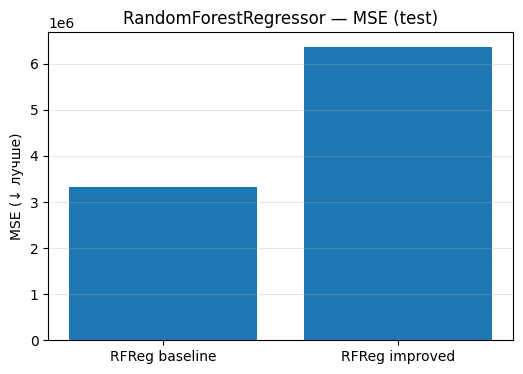

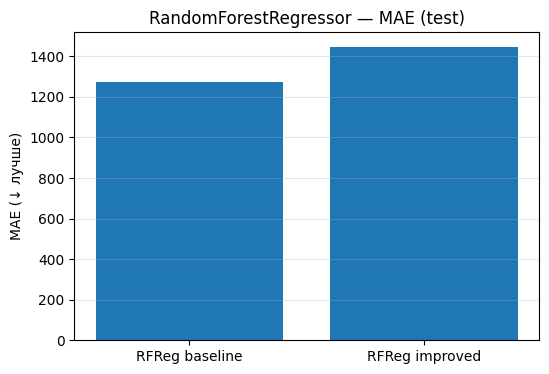

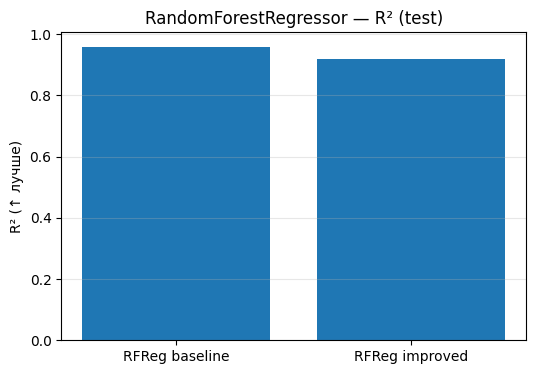

In [32]:
models_reg = ["RFReg baseline", "RFReg improved"]
mses = [mse_base, mse_imp]
maes = [mae_base, mae_imp]
r2s = [r2_base, r2_imp]

plt.figure(figsize=(6, 4))
plt.bar(models_reg, mses)
plt.ylabel("MSE (↓ лучше)")
plt.title("RandomForestRegressor — MSE (test)")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(models_reg, maes)
plt.ylabel("MAE (↓ лучше)")
plt.title("RandomForestRegressor — MAE (test)")
plt.grid(axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(models_reg, r2s)
plt.ylabel("R² (↑ лучше)")
plt.title("RandomForestRegressor — R² (test)")
plt.grid(axis="y", alpha=0.3)
plt.show()


## Своя реализация

In [43]:
import numpy as np
from collections import Counter
from math import sqrt, log2
from sklearn.base import BaseEstimator, ClassifierMixin, RegressorMixin


class MyDecisionTreeRegressor(BaseEstimator, RegressorMixin):
    class Node:
        def __init__(self, feature_index=None, threshold=None,
                     left=None, right=None, value=None):
            self.feature_index = feature_index
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value

        def is_leaf(self):
            return self.value is not None

    def __init__(self,
                 max_depth=None,
                 min_samples_split=2,
                 min_samples_leaf=1,
                 max_features=None,
                 random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state

        self.root = None
        self.n_features_ = None
        self._n_subfeatures = None
        self._rng = None

    def _resolve_max_features(self, n_features):
        if self.max_features is None:
            return n_features
        if isinstance(self.max_features, str):
            if self.max_features == "sqrt":
                return max(1, int(sqrt(n_features)))
            if self.max_features == "log2":
                return max(1, int(log2(n_features)))
            raise ValueError(f"Unknown max_features={self.max_features}")
        if isinstance(self.max_features, float):
            return max(1, int(n_features * self.max_features))
        if isinstance(self.max_features, int):
            return min(n_features, self.max_features)
        return n_features

    def fit(self, X, y):
        if hasattr(X, "toarray"):
            X = X.toarray()
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        self.n_features_ = X.shape[1]
        self._rng = np.random.RandomState(self.random_state)
        self._n_subfeatures = self._resolve_max_features(self.n_features_)

        self.root = self._build_tree(X, y, depth=0)
        return self

    def predict(self, X):
        if hasattr(X, "toarray"):
            X = X.toarray()
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_row(x, self.root) for x in X])

    def _mse(self, y):
        if len(y) == 0:
            return 0.0
        mean = np.mean(y)
        return np.mean((y - mean) ** 2)

    def _best_split(self, X, y):
        m, n = X.shape
        if m < self.min_samples_split:
            return None, None

        all_features = np.arange(n)
        if self._n_subfeatures < n:
            feat_subset = self._rng.choice(all_features,
                                           size=self._n_subfeatures,
                                           replace=False)
        else:
            feat_subset = all_features

        best_feature = None
        best_threshold = None
        best_impurity = float("inf")

        for feature in feat_subset:
            sorted_idx = np.argsort(X[:, feature])
            Xf = X[sorted_idx, feature]
            yf = y[sorted_idx]

            for i in range(1, m):
                if Xf[i] == Xf[i-1]:
                    continue
                thr = 0.5 * (Xf[i] + Xf[i-1])

                left_y = yf[:i]
                right_y = yf[i:]

                if len(left_y) < self.min_samples_leaf or len(right_y) < self.min_samples_leaf:
                    continue

                mse_left = self._mse(left_y)
                mse_right = self._mse(right_y)
                impurity = (len(left_y) * mse_left + len(right_y) * mse_right) / m

                if impurity < best_impurity:
                    best_impurity = impurity
                    best_feature = feature
                    best_threshold = thr

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth):
        num_samples = len(y)
        if (self.max_depth is not None and depth >= self.max_depth) or \
           num_samples < self.min_samples_split:
            leaf_value = float(np.mean(y))
            return self.Node(value=leaf_value)

        feature, threshold = self._best_split(X, y)
        if feature is None:
            leaf_value = float(np.mean(y))
            return self.Node(value=leaf_value)

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return self.Node(feature_index=feature,
                         threshold=threshold,
                         left=left_child,
                         right=right_child)

    def _predict_row(self, x, node):
        while not node.is_leaf():
            if x[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value

class MyDecisionTreeClassifier(BaseEstimator, ClassifierMixin):
    class Node:
        def __init__(self, feature_index=None, threshold=None,
                     left=None, right=None, value=None):
            self.feature_index = feature_index
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value

        def is_leaf(self):
            return self.value is not None

    def __init__(self,
                 max_depth=None,
                 min_samples_split=2,
                 min_samples_leaf=1,
                 max_features=None,
                 random_state=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.random_state = random_state

        self.root = None
        self.classes_ = None
        self.n_classes_ = None
        self.n_features_ = None
        self._n_subfeatures = None
        self._rng = None

    def _resolve_max_features(self, n_features):
        if self.max_features is None:
            return n_features
        if isinstance(self.max_features, str):
            if self.max_features == "sqrt":
                return max(1, int(sqrt(n_features)))
            if self.max_features == "log2":
                return max(1, int(log2(n_features)))
            raise ValueError(f"Unknown max_features={self.max_features}")
        if isinstance(self.max_features, float):
            return max(1, int(n_features * self.max_features))
        if isinstance(self.max_features, int):
            return min(n_features, self.max_features)
        return n_features

    def fit(self, X, y):
        if hasattr(X, "toarray"):
            X = X.toarray()
        X = np.asarray(X)
        y = np.asarray(y)

        self.classes_, y_enc = np.unique(y, return_inverse=True)
        self.n_classes_ = len(self.classes_)
        self.n_features_ = X.shape[1]

        self._rng = np.random.RandomState(self.random_state)
        self._n_subfeatures = self._resolve_max_features(self.n_features_)

        self.root = self._build_tree(X, y_enc, depth=0)
        return self

    def predict(self, X):
        if hasattr(X, "toarray"):
            X = X.toarray()
        X = np.asarray(X)
        y_pred_enc = np.array([self._predict_row(x, self.root) for x in X])
        return self.classes_[y_pred_enc]

    def _gini(self, y_enc):
        m = len(y_enc)
        if m == 0:
            return 0.0
        counts = np.bincount(y_enc, minlength=self.n_classes_)
        p = counts / m
        return 1.0 - np.sum(p ** 2)

    def _best_split(self, X, y_enc):
        m, n = X.shape
        if m < self.min_samples_split:
            return None, None

        all_features = np.arange(n)
        if self._n_subfeatures < n:
            feat_subset = self._rng.choice(all_features,
                                           size=self._n_subfeatures,
                                           replace=False)
        else:
            feat_subset = all_features

        best_feature = None
        best_threshold = None
        best_impurity = float("inf")
        current_impurity = self._gini(y_enc)
        if current_impurity == 0.0:
            return None, None

        for feature in feat_subset:
            sorted_idx = np.argsort(X[:, feature])
            Xf = X[sorted_idx, feature]
            yf = y_enc[sorted_idx]

            for i in range(1, m):
                if Xf[i] == Xf[i-1]:
                    continue

                thr = 0.5 * (Xf[i] + Xf[i-1])

                left_y = yf[:i]
                right_y = yf[i:]

                if len(left_y) < self.min_samples_leaf or len(right_y) < self.min_samples_leaf:
                    continue

                g_left = self._gini(left_y)
                g_right = self._gini(right_y)
                impurity = (len(left_y) * g_left + len(right_y) * g_right) / m

                if impurity < best_impurity:
                    best_impurity = impurity
                    best_feature = feature
                    best_threshold = thr

        return best_feature, best_threshold

    def _build_tree(self, X, y_enc, depth):
        num_samples = len(y_enc)
        num_labels = len(np.unique(y_enc))

        if (self.max_depth is not None and depth >= self.max_depth) or \
           num_labels == 1 or \
           num_samples < self.min_samples_split:
            leaf_value = self._leaf_value(y_enc)
            return self.Node(value=leaf_value)

        feature, threshold = self._best_split(X, y_enc)
        if feature is None:
            leaf_value = self._leaf_value(y_enc)
            return self.Node(value=leaf_value)

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        left_child = self._build_tree(X[left_mask], y_enc[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y_enc[right_mask], depth + 1)

        return self.Node(feature_index=feature,
                         threshold=threshold,
                         left=left_child,
                         right=right_child)

    def _leaf_value(self, y_enc):
        counter = Counter(y_enc)
        return counter.most_common(1)[0][0]

    def _predict_row(self, x, node):
        while not node.is_leaf():
            if x[node.feature_index] <= node.threshold:
                node = node.left
            else:
                node = node.right
        return node.value

class MyRandomForestClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self,
                 n_estimators=100,
                 max_depth=None,
                 min_samples_split=2,
                 min_samples_leaf=1,
                 max_features="sqrt",
                 bootstrap=True,
                 random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.random_state = random_state

        self.trees_ = []
        self.n_features_in_ = None

    def fit(self, X, y):
        if hasattr(X, "toarray"):
            X = X.toarray()
        X = np.asarray(X)
        y = np.asarray(y)

        n_samples, n_features = X.shape
        self.n_features_in_ = n_features

        rng = np.random.RandomState(self.random_state)
        self.trees_ = []

        for _ in range(self.n_estimators):
            if self.bootstrap:
                sample_idx = rng.randint(0, n_samples, size=n_samples)
            else:
                sample_idx = np.arange(n_samples)

            X_boot = X[sample_idx]
            y_boot = y[sample_idx]

            tree = MyDecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features,
                random_state=rng.randint(0, 10**9)
            )
            tree.fit(X_boot, y_boot)
            self.trees_.append(tree)

        return self

    def predict(self, X):
        if hasattr(X, "toarray"):
            X = X.toarray()
        X = np.asarray(X)
        n_samples = X.shape[0]

        all_preds = []
        for tree in self.trees_:
            preds = tree.predict(X)
            all_preds.append(preds)

        all_preds = np.array(all_preds)
        final = []
        for j in range(n_samples):
            votes = all_preds[:, j]
            c = Counter(votes)
            final.append(c.most_common(1)[0][0])

        return np.array(final)

class MyRandomForestRegressor(BaseEstimator, RegressorMixin):
    def __init__(self,
                 n_estimators=100,
                 max_depth=None,
                 min_samples_split=2,
                 min_samples_leaf=1,
                 max_features="sqrt",
                 bootstrap=True,
                 random_state=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.random_state = random_state

        self.trees_ = []
        self.n_features_in_ = None

    def fit(self, X, y):
        if hasattr(X, "toarray"):
            X = X.toarray()
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        n_samples, n_features = X.shape
        self.n_features_in_ = n_features

        rng = np.random.RandomState(self.random_state)
        self.trees_ = []

        for _ in range(self.n_estimators):
            if self.bootstrap:
                sample_idx = rng.randint(0, n_samples, size=n_samples)
            else:
                sample_idx = np.arange(n_samples)

            X_boot = X[sample_idx]
            y_boot = y[sample_idx]

            tree = MyDecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=self.max_features,
                random_state=rng.randint(0, 10**9)
            )
            tree.fit(X_boot, y_boot)
            self.trees_.append(tree)

        return self

    def predict(self, X):
        if hasattr(X, "toarray"):
            X = X.toarray()
        X = np.asarray(X, dtype=float)

        all_preds = []
        for tree in self.trees_:
            preds = tree.predict(X)
            all_preds.append(preds)

        all_preds = np.array(all_preds)
        return np.mean(all_preds, axis=0)


In [44]:
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

my_rf_clf_pipe = Pipeline(steps=[
    ("preprocess", preprocess_cls),
    ("model", MyRandomForestClassifier(random_state=RANDOM_STATE))
])

param_grid_my_rf_clf = {
    "model__n_estimators": [20, 50],
    "model__max_depth": [None, 6, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"],
}

grid_my_rf_clf = GridSearchCV(
    estimator=my_rf_clf_pipe,
    param_grid=param_grid_my_rf_clf,
    cv=cv_clf,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_my_rf_clf.fit(X_train_cls, y_train_cls)

print("Best params (MyRandomForestClassifier):", grid_my_rf_clf.best_params_)
print("Best CV score (F1-macro):", grid_my_rf_clf.best_score_)

my_rf_clf_best = grid_my_rf_clf.best_estimator_
y_pred_my_rf_clf = my_rf_clf_best.predict(X_test_cls)

acc_my_rf = accuracy_score(y_test_cls, y_pred_my_rf_clf)
f1_my_rf = f1_score(y_test_cls, y_pred_my_rf_clf, average="macro")
print(f"[MyRandomForestClassifier — best]  Acc={acc_my_rf:.4f} | F1-macro={f1_my_rf:.4f}")


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params (MyRandomForestClassifier): {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best CV score (F1-macro): 0.8092682688464563
[MyRandomForestClassifier — best]  Acc=0.9711 | F1-macro=0.9223


In [45]:
from sklearn.preprocessing import MinMaxScaler

def load_car_price_assignment(path):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    y = df["price"]
    X = df.drop(columns=["price", "car_ID"])
    # Выделяем бренд из имени модели
    if "CarName" in X.columns:
        carnames = X["CarName"].astype(str).str.strip().str.lower()
        X["brand"] = carnames.str.split("[ \-]", n=1, expand=True)[0]
        X = X.drop(columns=["CarName"])
    # Конвертация слов-чисел в числа (doornumber, cylindernumber)
    NUM_WORDS = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}
    for col in ["doornumber", "cylindernumber"]:
        if col in X.columns and X[col].dtype == object:
            X[col] = X[col].str.strip().str.lower().map(NUM_WORDS).astype("Int64")
    for c in X.columns:
        if X[c].dtype == object:
            X[c] = X[c].astype(str).str.strip().str.lower()
    return X, y

X_reg_raw, y_reg_raw = load_car_price_assignment(REG_PATH)
print("Regression dataset shape:", X_reg_raw.shape, "| target shape:", y_reg_raw.shape)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_raw, y_reg_raw,
    test_size=0.2,
    random_state=RANDOM_STATE
)

cat_cols_reg = [c for c in X_train_reg.columns if X_train_reg[c].dtype == "object"]
num_cols_reg = [c for c in X_train_reg.columns if c not in cat_cols_reg]

preprocess_reg = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols_reg),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_reg),
    ]
)

cv_reg = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

my_rf_reg_pipe = Pipeline(steps=[
    ("preprocess", preprocess_reg),
    ("model", MyRandomForestRegressor(random_state=RANDOM_STATE))
])

param_grid_my_rf_reg = {
    "model__n_estimators": [20, 50],
    "model__max_depth": [None, 6, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"],
}

grid_my_rf_reg = GridSearchCV(
    estimator=my_rf_reg_pipe,
    param_grid=param_grid_my_rf_reg,
    cv=cv_reg,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_my_rf_reg.fit(X_train_reg, y_train_reg)

print("Best params (MyRandomForestRegressor):", grid_my_rf_reg.best_params_)
print("Best CV score (neg MSE):", grid_my_rf_reg.best_score_)

my_rf_reg_best = grid_my_rf_reg.best_estimator_
y_pred_my_rf_reg = my_rf_reg_best.predict(X_test_reg)

mse_my_rf = mean_squared_error(y_test_reg, y_pred_my_rf_reg)
mae_my_rf = mean_absolute_error(y_test_reg, y_pred_my_rf_reg)
r2_my_rf = r2_score(y_test_reg, y_pred_my_rf_reg)
print(f"[MyRandomForestRegressor — best]  MSE={mse_my_rf:.2f} | MAE={mae_my_rf:.2f} | R²={r2_my_rf:.4f}")


Regression dataset shape: (205, 24) | target shape: (205,)
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params (MyRandomForestRegressor): {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 20}
Best CV score (neg MSE): -5647917.283038679
[MyRandomForestRegressor — best]  MSE=5221353.50 | MAE=1456.94 | R²=0.9339


## Графики

=== Classification models comparison ===
           Model  Accuracy  F1-macro
0  SkRF baseline  0.968208  0.896910
1  SkRF improved  0.979769  0.967006
2      MyRF best  0.971098  0.922300


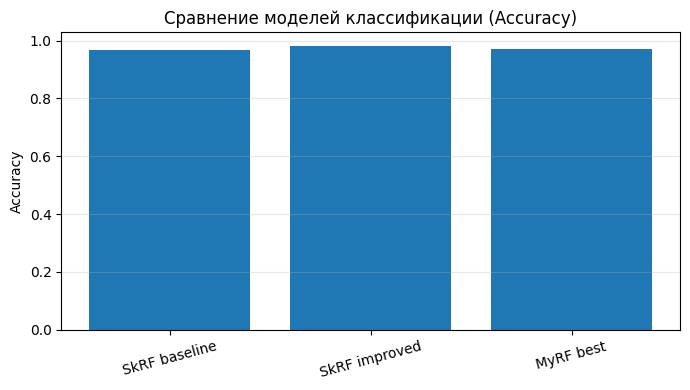

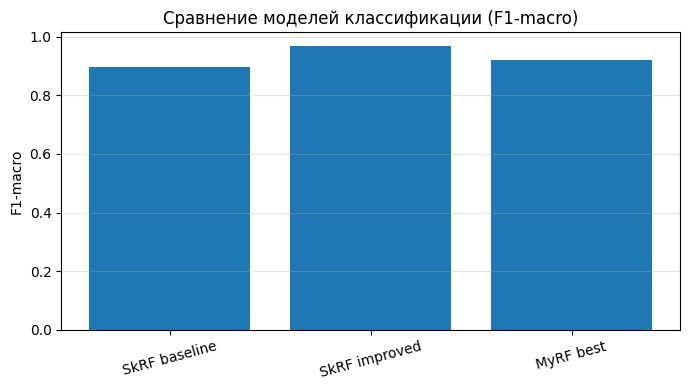

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

model_names_cls = []
acc_values = []
f1_values = []

if "acc_base" in locals() and "f1_base" in locals():
    model_names_cls.append("SkRF baseline")
    acc_values.append(acc_base)
    f1_values.append(f1_base)

if "acc_imp" in locals() and "f1_imp" in locals():
    model_names_cls.append("SkRF improved")
    acc_values.append(acc_imp)
    f1_values.append(f1_imp)

if "acc_my_rf" in locals() and "f1_my_rf" in locals():
    model_names_cls.append("MyRF best")
    acc_values.append(acc_my_rf)
    f1_values.append(f1_my_rf)

df_cls_metrics = pd.DataFrame({
    "Model": model_names_cls,
    "Accuracy": acc_values,
    "F1-macro": f1_values
})

print("=== Classification models comparison ===")
print(df_cls_metrics)

plt.figure(figsize=(7, 4))
plt.bar(model_names_cls, acc_values)
plt.ylabel("Accuracy")
plt.title("Сравнение моделей классификации (Accuracy)")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(model_names_cls, f1_values)
plt.ylabel("F1-macro")
plt.title("Сравнение моделей классификации (F1-macro)")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


=== Regression models comparison ===
              Model           MSE          MAE        R²
0  SkRFReg baseline  3.317885e+06  1272.851333  0.957972
1  SkRFReg improved  6.361571e+06  1446.294240  0.919417
2      MyRFReg best  5.221353e+06  1456.941704  0.933860


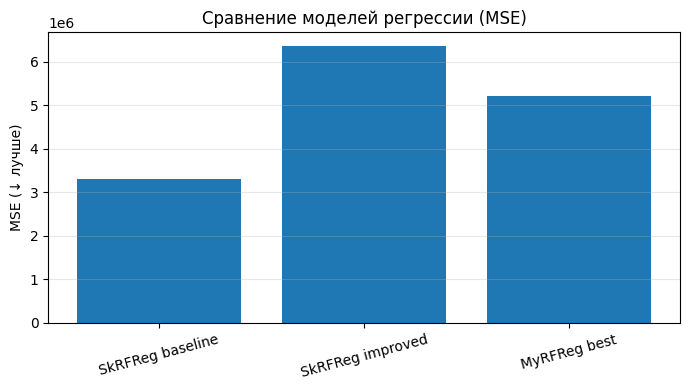

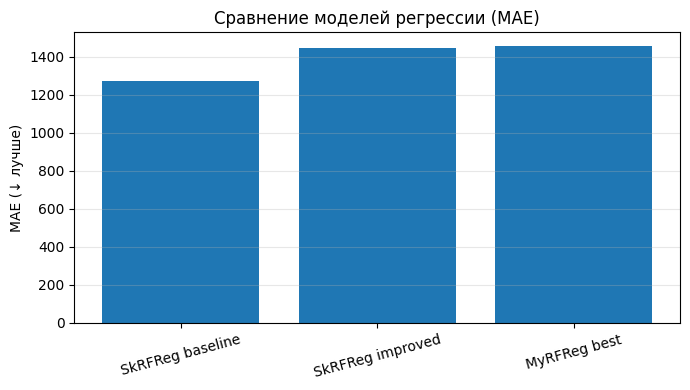

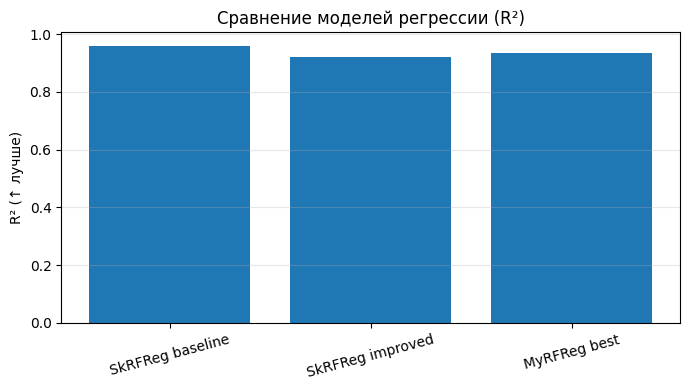

In [47]:
model_names_reg = []
mse_values = []
mae_values = []
r2_values = []

if "mse_base" in locals() and "mae_base" in locals() and "r2_base" in locals():
    model_names_reg.append("SkRFReg baseline")
    mse_values.append(mse_base)
    mae_values.append(mae_base)
    r2_values.append(r2_base)

if "mse_imp" in locals() and "mae_imp" in locals() and "r2_imp" in locals():
    model_names_reg.append("SkRFReg improved")
    mse_values.append(mse_imp)
    mae_values.append(mae_imp)
    r2_values.append(r2_imp)

if "mse_my_rf" in locals() and "mae_my_rf" in locals() and "r2_my_rf" in locals():
    model_names_reg.append("MyRFReg best")
    mse_values.append(mse_my_rf)
    mae_values.append(mae_my_rf)
    r2_values.append(r2_my_rf)

df_reg_metrics = pd.DataFrame({
    "Model": model_names_reg,
    "MSE": mse_values,
    "MAE": mae_values,
    "R²": r2_values
})

print("=== Regression models comparison ===")
print(df_reg_metrics)

plt.figure(figsize=(7, 4))
plt.bar(model_names_reg, mse_values)
plt.ylabel("MSE (↓ лучше)")
plt.title("Сравнение моделей регрессии (MSE)")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(model_names_reg, mae_values)
plt.ylabel("MAE (↓ лучше)")
plt.title("Сравнение моделей регрессии (MAE)")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.bar(model_names_reg, r2_values)
plt.ylabel("R² (↑ лучше)")
plt.title("Сравнение моделей регрессии (R²)")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
